# Validation: `StateEstimator` vs `ofc_svd` as v-mode engines (v1)

**Author:** Aaron Roodman
**Date Created:** 2026-09-16
**Last Modified:** 2026-09-16
**Status:** Complete
**Keywords:** AOS, OFC, v-modes, sensitivity matrix, SVD, normalization, StateEstimator, validation

## Description

Demonstrates that the two sanctioned engines for the Optical Feedback Control (OFC)
sensitivity-matrix singular value decomposition (SVD) deliver **identical** v-modes:

1. `lsst.ts.ofc.state_estimator.StateEstimator` — what the Main Telescope Active Optics
   System (MTAOS) runs on the summit, reached only through
   `aos_state.make_state_estimator`;
2. `lsst.ts.intrinsic.wavefront.ofc_svd.build_ofc_svd` — the Double Zernike (DZ) route
   used by the Full Array Mode (FAM) studies.

Both are checked for the standard 21 pupil Zernikes (Noll Z4-Z26 omitting Z20 and Z21),
the required normalization `range0.5_fwhm-0.15.yaml`, and **both** correction schemes:
22 degrees of freedom (DOF) keeping 12 v-modes, and 50 DOF keeping 34.

Key functionality:
1. Assert the normalization weights, singular values and per-v-mode DOF composition agree.
2. Print the v1 formula in physical DOF units from both engines.
3. Show that the obsolete normalization makes v1 an essentially orthogonal mode.

**Output:** Printed assertions with numerical tolerances, a two-panel comparison figure per
scheme, and a PASS/FAIL summary table.

**Based on:** `aos/docs/studies/smatrix_vmode.md`; the companion notebook
`vmode_dof_ts_ofc.ipynb`, which is deliberately independent of `rubin-work` code.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-16 | Aaron Roodman | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Background: what must agree, and what must not be used](#background)
4. [Helper Functions](#functions)
5. [Engine setup](#data)
6. [Analysis: engine equivalence](#analysis)
7. [The v1 formula from both engines](#v1)
8. [The obsolete normalization](#obsolete)
9. [Results & Plots](#results)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

# Correction schemes to validate: name -> (dof_set, n_keep).
SCHEMES = {
    "22_12": ("standard_22", 12),
    "50_34": ("all_50", 34),
}

# Pupil Zernike set (Noll): Z4-Z26 omitting Z20, Z21 -> 21 terms, what ts_wep rapid
# analysis produces. Taken from aos_state so it cannot drift from the pipeline.
# Agreement tolerances. The two engines decompose the same matrix with the same LAPACK
# call, so exact equality is expected; these are guards, not fitted tolerances.
ATOL_WEIGHTS = 0.0        # per-DOF normalization weight units
ATOL_SIGMA   = 1e-9       # DZ sensitivity units
ATOL_DOF     = 1e-8       # um (or arcsec) of DOF per unit v-mode
COS_MIN      = 1.0 - 1e-10  # dimensionless, per-mode alignment after sign matching

OUTPUT_DIR = None         # None -> no file output; else a directory for the figures

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Walk up to the topic directory (aos/), which works at any notebook depth.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

import aos_state
from lsst.ts.intrinsic.wavefront.ofc_svd import build_ofc_svd

ZK_NOLL = aos_state.ZK_NOLL
print(f"pupil Zernikes: {len(ZK_NOLL)} terms, Noll {ZK_NOLL[0]}-{ZK_NOLL[-1]} "
      f"omitting {sorted(set(range(ZK_NOLL[0], ZK_NOLL[-1] + 1)) - set(ZK_NOLL))}")
print(f"required normalization: {aos_state.REQUIRED_NORM_YAML}")
print(f"obsolete normalization: {aos_state.OBSOLETE_NORM_YAML}  (must never be used)")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 10})

pupil Zernikes: 21 terms, Noll 4-26 omitting [20, 21]
required normalization: range0.5_fwhm-0.15.yaml
obsolete normalization: range-fwhm.yaml  (must never be used)


<a id='background'></a>
## Background: what must agree, and what must not be used

### The two engines decompose the same matrix

`StateEstimator` builds its v-modes from the whole DZ sensitivity slab flattened to a
2-D matrix (`state_estimator.py:93-96`):

$$ \tilde{S} = S_{\text{flat}}[:, \mathrm{dof\_idx}] \; N, \qquad
   \tilde{S} = U \Sigma V^\top, \qquad N = \mathrm{diag}(w_{\mathrm{dof\_idx}}) $$

where $S_{\text{flat}}$ is the $(31 \times 29, 50)$ reshape of the slab — 31 focal
(field) Noll orders by 29 pupil Zernikes — and $w$ are the per-DOF normalization weights.
`build_ofc_svd(iZs, k_min, k_max, ...)` decomposes a **slice** of the same slab,
`S_full[k_min:k_max+1, iZs, :] @ diag(norm)`. Handing it the full slice
(`k_min=0`, `k_max=30`, all 29 pupil terms) must therefore reproduce `StateEstimator`
exactly, because it is then the identical matrix through the identical LAPACK call.

The quantity compared is the **physical DOF produced per unit v-mode**, which is
$N V$ — exactly what `StateEstimator.get_dofs_from_vmodes` returns, and
`normalization_weights[:, None] * svd.V` on the other side.

### Two things that are *not* discrepancies

**The `k` range.** Every `build_ofc_svd` caller in `aos/` uses `k_min=1, k_max=6`, a
deliberate truncation of the field dependence for the DZ studies. `StateEstimator` uses
all of `k = 0..30`, and its wavefront solve evaluates the DZ polynomial at the corner
field angles, which **collapses every $k$** — there is no $k$ axis left to truncate. The
two are legitimate bases for different questions. This notebook matches the full slab
only to isolate the engine comparison; it is not a claim that `k=1..6` is wrong.

**`zn_selected`.** Setting it does not change `Vh`: the SVD above applies no Zernike
selection, and `zn_idx` enters only `get_sensitivity_matrix`, used for the
wavefront-to-DOF solve. That inconsistency is recorded as an open question for the OFC
maintainers in `aos/docs/studies/smatrix_vmode.md`.

### The normalization is not optional

Only `range0.5_fwhm-0.15.yaml` is acceptable. The bare `OFCData('lsst')` default resolves
`range-fwhm.yaml`, the obsolete normalization whose sensitivity matrix retains a
dependence on physical units. It is not a rescaling — its weights differ non-uniformly per
DOF, so it **rotates** the v-mode basis, and section 8 shows it makes v1 essentially
orthogonal to the correct mode. `aos_state.make_state_estimator` asserts the resolved
controller filename and raises otherwise, which is why it is the only door to a v-mode in
this repository.

<a id='functions'></a>
## Helper Functions

In [3]:
def dof_per_vmode_state_estimator(se, n_keep):
    """Physical DOF produced per unit v-mode, from ``StateEstimator``.

    Parameters
    ----------
    se : `lsst.ts.ofc.state_estimator.StateEstimator`
        From `aos_state.make_state_estimator`.
    n_keep : `int`
        Number of v-modes to return.

    Returns
    -------
    M : `numpy.ndarray`
        Shape ``(n_dof, n_keep)``. Column m is the DOF vector produced by a
        unit amplitude in v-mode m, in µm for translations and bending modes and
        arcsec for tilts. Equals ``N @ V[:, m]``.
    """
    n_modes = se.Vh.shape[0]
    return np.column_stack(
        [se.get_dofs_from_vmodes(np.eye(n_modes)[m]) for m in range(n_keep)])


def dof_per_vmode_ofc_svd(svd, n_keep):
    """Physical DOF produced per unit v-mode, from an `OFCSvd`.

    Parameters
    ----------
    svd : `lsst.ts.intrinsic.wavefront.ofc_svd.OFCSvd`
    n_keep : `int`

    Returns
    -------
    M : `numpy.ndarray`
        Shape ``(n_dof, n_keep)``, same units and meaning as
        `dof_per_vmode_state_estimator`. Equals ``diag(w) @ V[:, :n_keep]``.
    """
    return np.asarray(svd.normalization_weights)[:, None] * svd.V[:, :n_keep]


def match_signs(M_ref, M_test):
    """Flip whole columns of `M_test` to match the sign convention of `M_ref`.

    The sign of a singular vector is arbitrary and is chosen independently per mode by
    LAPACK, so a per-column flip is required before any elementwise comparison. Only
    signs change; magnitudes are untouched.

    Parameters
    ----------
    M_ref, M_test : `numpy.ndarray`
        Shape ``(n_dof, n_keep)``.

    Returns
    -------
    M_flipped : `numpy.ndarray`
        Copy of `M_test` with columns sign-aligned to `M_ref`.
    n_flips : `int`
        How many columns were flipped.
    """
    M = np.array(M_test, dtype=float, copy=True)
    n_flips = 0
    for m in range(M.shape[1]):
        if np.dot(M_ref[:, m], M[:, m]) < 0:
            M[:, m] *= -1.0
            n_flips += 1
    return M, n_flips


def per_mode_cos(M_a, M_b):
    """Absolute cosine between corresponding columns of two DOF-per-v-mode matrices.

    Parameters
    ----------
    M_a, M_b : `numpy.ndarray`
        Shape ``(n_dof, n_keep)``.

    Returns
    -------
    cos : `numpy.ndarray`
        Shape ``(n_keep,)``, dimensionless, in ``[0, 1]``. Sign-insensitive, so it is
        meaningful with or without `match_signs`.
    """
    num = np.abs((M_a * M_b).sum(axis=0))
    den = np.linalg.norm(M_a, axis=0) * np.linalg.norm(M_b, axis=0)
    return num / den


def compare_engines(scheme, dof_set, n_keep):
    """Compare the two v-mode engines for one correction scheme.

    Builds `StateEstimator` through `aos_state.make_state_estimator` (which asserts the
    required normalization) and `build_ofc_svd` on the **matched full slab**: all focal
    orders ``k = 0..30`` and all 29 pupil Zernikes, the same DOF subset, the same
    normalization yaml and the same truncation.

    Parameters
    ----------
    scheme : `str`
        Label, e.g. ``'22_12'``.
    dof_set : `str`
        Key into `aos_state.DOF_SETS`.
    n_keep : `int`
        v-modes retained.

    Returns
    -------
    res : `dict`
        Keys ``scheme``, ``n_dof``, ``n_keep``, ``norm_yaml``, ``labels``,
        ``M_se``/``M_svd`` (`numpy.ndarray`, µm or arcsec of DOF per unit v-mode),
        ``d_weights`` (per-DOF weight units), ``d_sigma`` (DZ sensitivity units),
        ``d_dof`` (µm or arcsec of DOF), ``units``, ``cos`` (dimensionless),
        ``n_flips`` (`int`),
        ``sigma_se``/``sigma_svd``, and ``passed`` (`bool`).
    """
    se = aos_state.make_state_estimator(dof_set=dof_set, n_modes=n_keep)
    norm_yaml = se.ofc_data.controller["normalization_weights_filename"]
    if norm_yaml != aos_state.REQUIRED_NORM_YAML:            # belt and braces
        raise RuntimeError(f"unexpected normalization {norm_yaml!r}")

    slab = np.asarray(se.ofc_data.sensitivity_matrix)         # (n_k, n_zn, n_dof_full)
    n_k, n_zn, _ = slab.shape
    dof_idx = [int(d) for d in se.ofc_data.dof_idx]

    # Matched full slab: every focal order, every pupil Zernike.
    svd = build_ofc_svd(list(range(n_zn)), k_min=0, k_max=n_k - 1,
                        n_keep=n_keep, n_dof=dof_idx, norm_yaml_name=norm_yaml)

    w_se = np.asarray(se.ofc_data.normalization_weights)[dof_idx]
    w_svd = np.asarray(svd.normalization_weights)
    sigma_se = np.asarray(se.S)[:n_keep]
    sigma_svd = np.asarray(svd.Sigma)[:n_keep]

    M_se = dof_per_vmode_state_estimator(se, n_keep)
    M_svd_raw = dof_per_vmode_ofc_svd(svd, n_keep)
    M_svd, n_flips = match_signs(M_se, M_svd_raw)
    cos = per_mode_cos(M_se, M_svd_raw)

    d_weights = float(np.abs(w_se - w_svd).max())
    d_sigma = float(np.abs(sigma_se - sigma_svd).max())
    d_dof = float(np.abs(M_se - M_svd).max())
    passed = bool(d_weights <= ATOL_WEIGHTS and d_sigma <= ATOL_SIGMA
                  and d_dof <= ATOL_DOF and cos.min() >= COS_MIN)
    svd_labels, svd_units = svd.dof_labels()
    return dict(scheme=scheme, n_dof=len(dof_idx), n_keep=n_keep, norm_yaml=norm_yaml,
                labels=svd_labels, units=svd_units, M_se=M_se, M_svd=M_svd,
                d_weights=d_weights, d_sigma=d_sigma, d_dof=d_dof, cos=cos,
                n_flips=n_flips, sigma_se=sigma_se, sigma_svd=sigma_svd,
                se=se, svd=svd, passed=passed)


def v1_formula(se, labels, units, top=5):
    """The v1 = sum_i C_i * DOF_i formula, in inverse physical DOF units.

    ``C_i`` is the v1 amplitude produced by moving used-DOF ``i`` by one unit, so its
    units are inverse µm for translations and bending modes and inverse arcsec for tilts.

    Parameters
    ----------
    se : `StateEstimator`
    labels : `list` [`str`]
        DOF names for the used-DOF subset, in `se.ofc_data.dof_idx` order, from
        `OFCSvd.dof_labels`.
    units : `list` [`str`]
        Matching physical units, ``'um'`` or ``'arcsec'``, second element of
        `OFCSvd.dof_labels`.
    top : `int`, optional
        Number of largest terms, ranked by normalized weight, to return.

    Returns
    -------
    terms : `list` [`tuple`]
        ``(label, unit, coeff, normalized)`` sorted by descending ``|normalized|``. ``coeff``
        is per DOF unit; ``normalized`` is the dimensionless element of ``V``.
    frac : `float`
        Fraction of the mode's normalized **power** (not amplitude) captured by the
        returned terms, dimensionless.
    """
    dof_idx = [int(d) for d in se.ofc_data.dof_idx]
    coeff = np.zeros(len(dof_idx))
    for j, gidx in enumerate(dof_idx):
        e = np.zeros(50)
        e[gidx] = 1.0
        coeff[j] = float(np.asarray(se.get_vmodes_from_dofs(e))[0])
    v_norm = np.asarray(se.Vh)[0]                      # dimensionless, unit length
    order = np.argsort(-np.abs(v_norm))[:top]
    frac = float((v_norm[order] ** 2).sum() / (v_norm ** 2).sum())
    return [(labels[j], units[j], float(coeff[j]), float(v_norm[j]))
            for j in order], frac

<a id='data'></a>
## Engine setup

In [4]:
results = {}
for scheme, (dof_set, n_keep) in SCHEMES.items():
    results[scheme] = compare_engines(scheme, dof_set, n_keep)
    r = results[scheme]
    print(f"{scheme}: dof_set={dof_set:12s} n_dof={r['n_dof']:2d} n_keep={r['n_keep']:2d} "
          f"norm={r['norm_yaml']}")

22_12: dof_set=standard_22  n_dof=22 n_keep=12 norm=range0.5_fwhm-0.15.yaml


50_34: dof_set=all_50       n_dof=50 n_keep=34 norm=range0.5_fwhm-0.15.yaml


<a id='analysis'></a>
## Analysis: engine equivalence

Four assertions per scheme. The two engines run the same LAPACK call on the same matrix,
so exact agreement is the expectation, not a tolerance to be tuned.

In [5]:
hdr = (f"{'scheme':>8} {'n_dof':>6} {'n_keep':>7} {'max|dw|':>12} {'max|dS|':>12} "
       f"{'max|dDOF|':>12} {'min|cos|':>14} {'flips':>6} {'':>6}")
print(hdr)
print("-" * len(hdr))
for scheme, r in results.items():
    print(f"{scheme:>8} {r['n_dof']:6d} {r['n_keep']:7d} "
          f"{r['d_weights']:12.3e} {r['d_sigma']:12.3e} {r['d_dof']:12.3e} "
          f"{r['cos'].min():14.10f} {r['n_flips']:6d} "
          f"{'PASS' if r['passed'] else 'FAIL':>6}")

print(f"\nunits: dw = per-DOF normalization weight; dS = DZ sensitivity units; "
      f"dDOF = um or arcsec of DOF per unit v-mode; cos = dimensionless")
print(f"tolerances: dw <= {ATOL_WEIGHTS}, dS <= {ATOL_SIGMA:.0e}, "
      f"dDOF <= {ATOL_DOF:.0e}, cos >= {COS_MIN:.12f}")

assert all(r["passed"] for r in results.values()), "engine equivalence FAILED"
print("\nall schemes PASS: StateEstimator and ofc_svd are the same engine on a matched slab")

  scheme  n_dof  n_keep      max|dw|      max|dS|    max|dDOF|       min|cos|  flips       
-------------------------------------------------------------------------------------------
   22_12     22      12    0.000e+00    0.000e+00    0.000e+00   1.0000000000      0   PASS
   50_34     50      34    0.000e+00    0.000e+00    0.000e+00   1.0000000000      0   PASS

units: dw = per-DOF normalization weight; dS = DZ sensitivity units; dDOF = um or arcsec of DOF per unit v-mode; cos = dimensionless
tolerances: dw <= 0.0, dS <= 1e-09, dDOF <= 1e-08, cos >= 0.999999999900

all schemes PASS: StateEstimator and ofc_svd are the same engine on a matched slab


<a id='v1'></a>
## The v1 formula from both engines

v1 is the most-observable direction in DOF space and the one quantity that is unique
regardless of basis conventions — degenerate singular-value pairs leave individual higher
v-modes basis-dependent, but v1 is well separated. Its coefficients are the practical
check that both engines agree on something physically meaningful.

v1 is also strongly **concentrated**: four DOF — camera-hexapod dz, M2-hexapod dz, M1M3
bending mode B3 and M2 bending mode B5 — carry essentially all of its normalized power. The
five printed terms reach 99.99997% for 22/12 and 99.99631% for 50/34 (dimensionless, power
not amplitude), the fifth being a negligible remainder that differs between the schemes. So
v1 is a focus-like combination of those four, which is what makes `v1_per_um_dz` a usable
conversion factor.

In [6]:
for scheme, r in results.items():
    terms, frac = v1_formula(r["se"], list(r["labels"]), list(r["units"]))
    lhs = "  ".join(f"{c:+.4g} 1/{u}*[{lab}]" for lab, u, c, _ in terms)
    print(f"{scheme}:  v1 = {lhs}")
    print(f"{'':>{len(scheme) + 2}}  top {len(terms)} terms carry "
          f"{100 * frac:.5f}% of the normalized mode power (dimensionless; power, not "
          f"amplitude)")

    # Cross-check v1 from ofc_svd: column 1 of N.V, compared per DOF.
    m_se, m_svd = r["M_se"][:, 0], r["M_svd"][:, 0]
    scale = np.abs(m_se).max()
    print(f"{'':>{len(scheme) + 2}}  v1 DOF-per-unit-mode agreement: "
          f"max|d| = {np.abs(m_se - m_svd).max():.3e} "
          f"(um or arcsec of DOF; scale {scale:.4g})\n")

22_12:  v1 = -0.0008915 1/μm*[Cam_dz]  -0.0009104 1/μm*[M2_dz]  +0.1172 1/μm*[B1_3]  +0.1142 1/μm*[B2_5]  +0.001562 1/μm*[B2_4]
         top 5 terms carry 99.99997% of the normalized mode power (dimensionless; power, not amplitude)
         v1 DOF-per-unit-mode agreement: max|d| = 0.000e+00 (um or arcsec of DOF; scale 645.7)

50_34:  v1 = -0.0008914 1/μm*[Cam_dz]  -0.0009103 1/μm*[M2_dz]  +0.1172 1/μm*[B1_3]  +0.1142 1/μm*[B2_5]  -0.4021 1/μm*[B2_18]
         top 5 terms carry 99.99631% of the normalized mode power (dimensionless; power, not amplitude)
         v1 DOF-per-unit-mode agreement: max|d| = 0.000e+00 (um or arcsec of DOF; scale 645.7)



<a id='obsolete'></a>
## The obsolete normalization

`range-fwhm.yaml` is what a bare `OFCData('lsst')` resolves. It is the old normalization
whose sensitivity matrix retains a dependence on physical units. This section measures
what using it would cost, and confirms `make_state_estimator` refuses it.

Note that the config *directory* does not settle the question: inside the v13 directory,
`init.yaml` selects the required yaml, while `dz_controller.yaml` and
`oic_controller.yaml` select the obsolete one and `pid_controller.yaml` selects
`default.yaml`. The guard therefore asserts the resolved controller filename.

In [7]:
from lsst.ts.ofc import OFCData
from lsst.ts.ofc.state_estimator import StateEstimator

def _estimator_with(config_dir):
    """StateEstimator built directly, bypassing the guard, for this comparison only."""
    ofc = OFCData("lsst") if config_dir is None else OFCData("lsst", config_dir=config_dir)
    ofc.configure_controller()
    ofc.zn_selected = np.array(ZK_NOLL)
    ofc.comp_dof_idx = aos_state._comp_dof_idx(aos_state.DOF_SETS["standard_22"])
    return StateEstimator(ofc), ofc.controller["normalization_weights_filename"]

se_bad, yaml_bad = _estimator_with(None)                                    # obsolete
se_ok, yaml_ok = _estimator_with(aos_state.resolve_ofc_config_dir("v13"))   # required

e_camhex_dz = np.zeros(50)
e_camhex_dz[5] = 1.0
v1_bad = float(np.asarray(se_bad.get_vmodes_from_dofs(e_camhex_dz))[0])
v1_ok = float(np.asarray(se_ok.get_vmodes_from_dofs(e_camhex_dz))[0])
cos_v1 = float(abs(np.dot(np.asarray(se_bad.Vh)[0], np.asarray(se_ok.Vh)[0])))

print(f"obsolete ({yaml_bad}):  v1 per um of CamHex dz = {v1_bad:.7e} (1/um)")
print(f"required ({yaml_ok}):  v1 per um of CamHex dz = {v1_ok:.7e} (1/um)")
print(f"|cos(v1_obsolete, v1_required)| = {cos_v1:.6f} (dimensionless)")
print("\nThe obsolete normalization does not rescale v1, it replaces it: the two v1")
print("directions are essentially orthogonal, and v1 becomes the M2-tilt mode.")

w_bad = np.asarray(se_bad.ofc_data.normalization_weights)
w_ok = np.asarray(se_ok.ofc_data.normalization_weights)
print(f"\nper-DOF weight ratio required/obsolete (dimensionless), first 5 DOF:")
for lab, ratio in zip(["M2Hex dz", "M2Hex dx", "M2Hex dy", "M2Hex rx", "M2Hex ry"],
                      w_ok[:5] / w_bad[:5]):
    print(f"  {lab:10s} {ratio:12.5g}")
print("Non-uniform, so this is a basis rotation and not a change of scale.")

try:
    aos_state.make_state_estimator(config_dir=aos_state.resolve_ofc_config_dir("v13"))
    print(f"\nguard: make_state_estimator accepts the v13 config, as intended")
except RuntimeError as exc:
    raise AssertionError(f"guard wrongly rejected the v13 config: {exc}")

obsolete (range-fwhm.yaml):  v1 per um of CamHex dz = -1.2933321e-09 (1/um)
required (range0.5_fwhm-0.15.yaml):  v1 per um of CamHex dz = -8.9153336e-04 (1/um)
|cos(v1_obsolete, v1_required)| = 0.000012 (dimensionless)

The obsolete normalization does not rescale v1, it replaces it: the two v1
directions are essentially orthogonal, and v1 becomes the M2-tilt mode.

per-DOF weight ratio required/obsolete (dimensionless), first 5 DOF:
  M2Hex dz         10.452
  M2Hex dx         948.79
  M2Hex dy         948.78
  M2Hex rx      0.0057914
  M2Hex ry      0.0057914
Non-uniform, so this is a basis rotation and not a change of scale.



guard: make_state_estimator accepts the v13 config, as intended


<a id='results'></a>
## Results & Plots

Per scheme: the DOF-per-v-mode matrix from `StateEstimator`, and the elementwise
difference against `ofc_svd` on the same colour scale, so that agreement is visible as a
uniformly blank right-hand panel rather than inferred from a printed number.

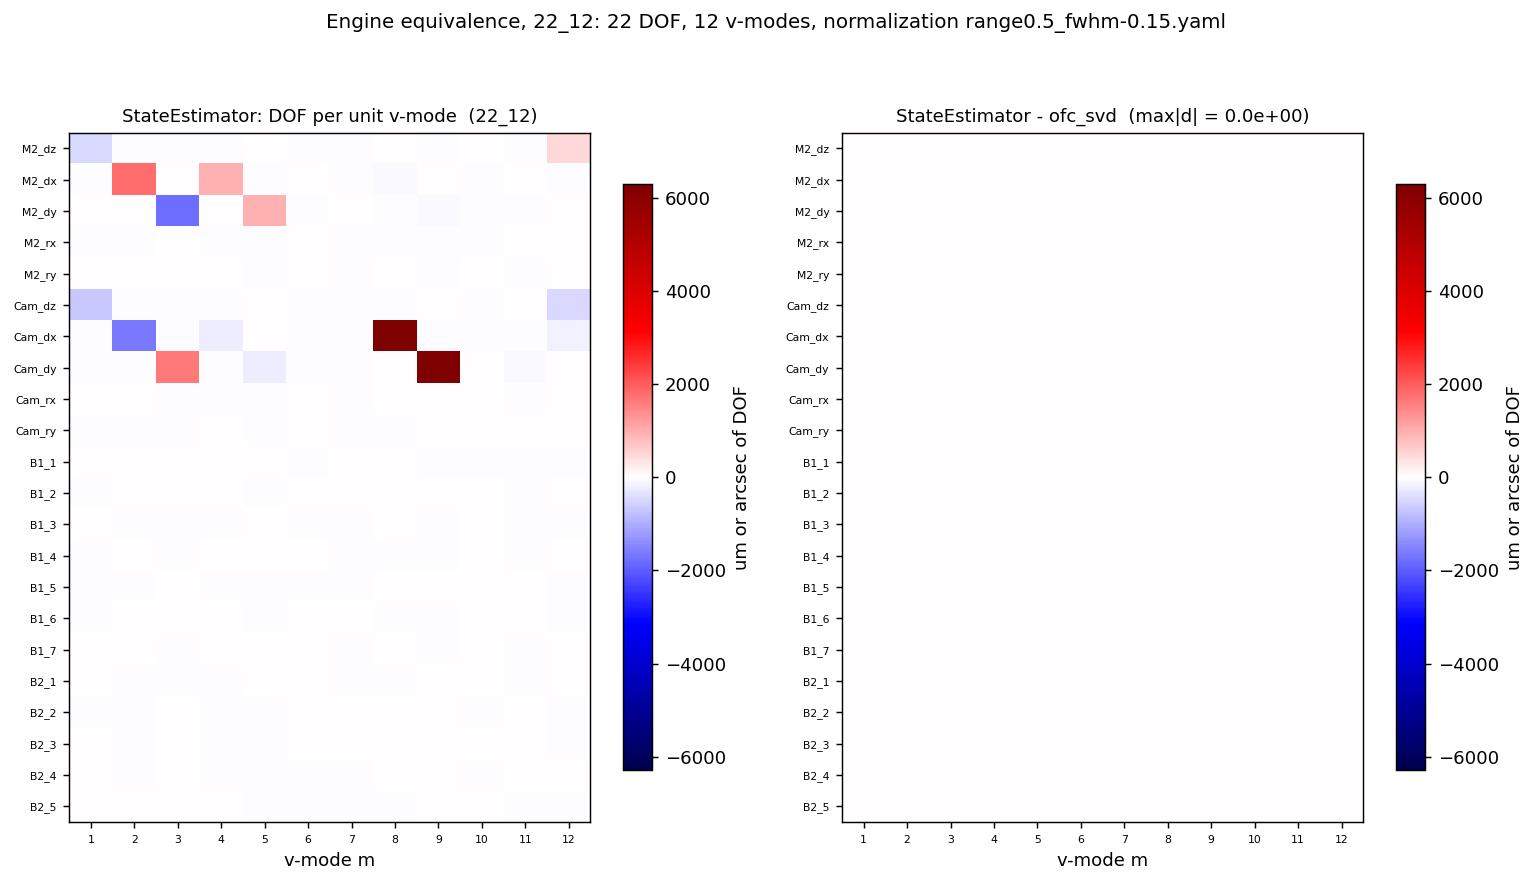

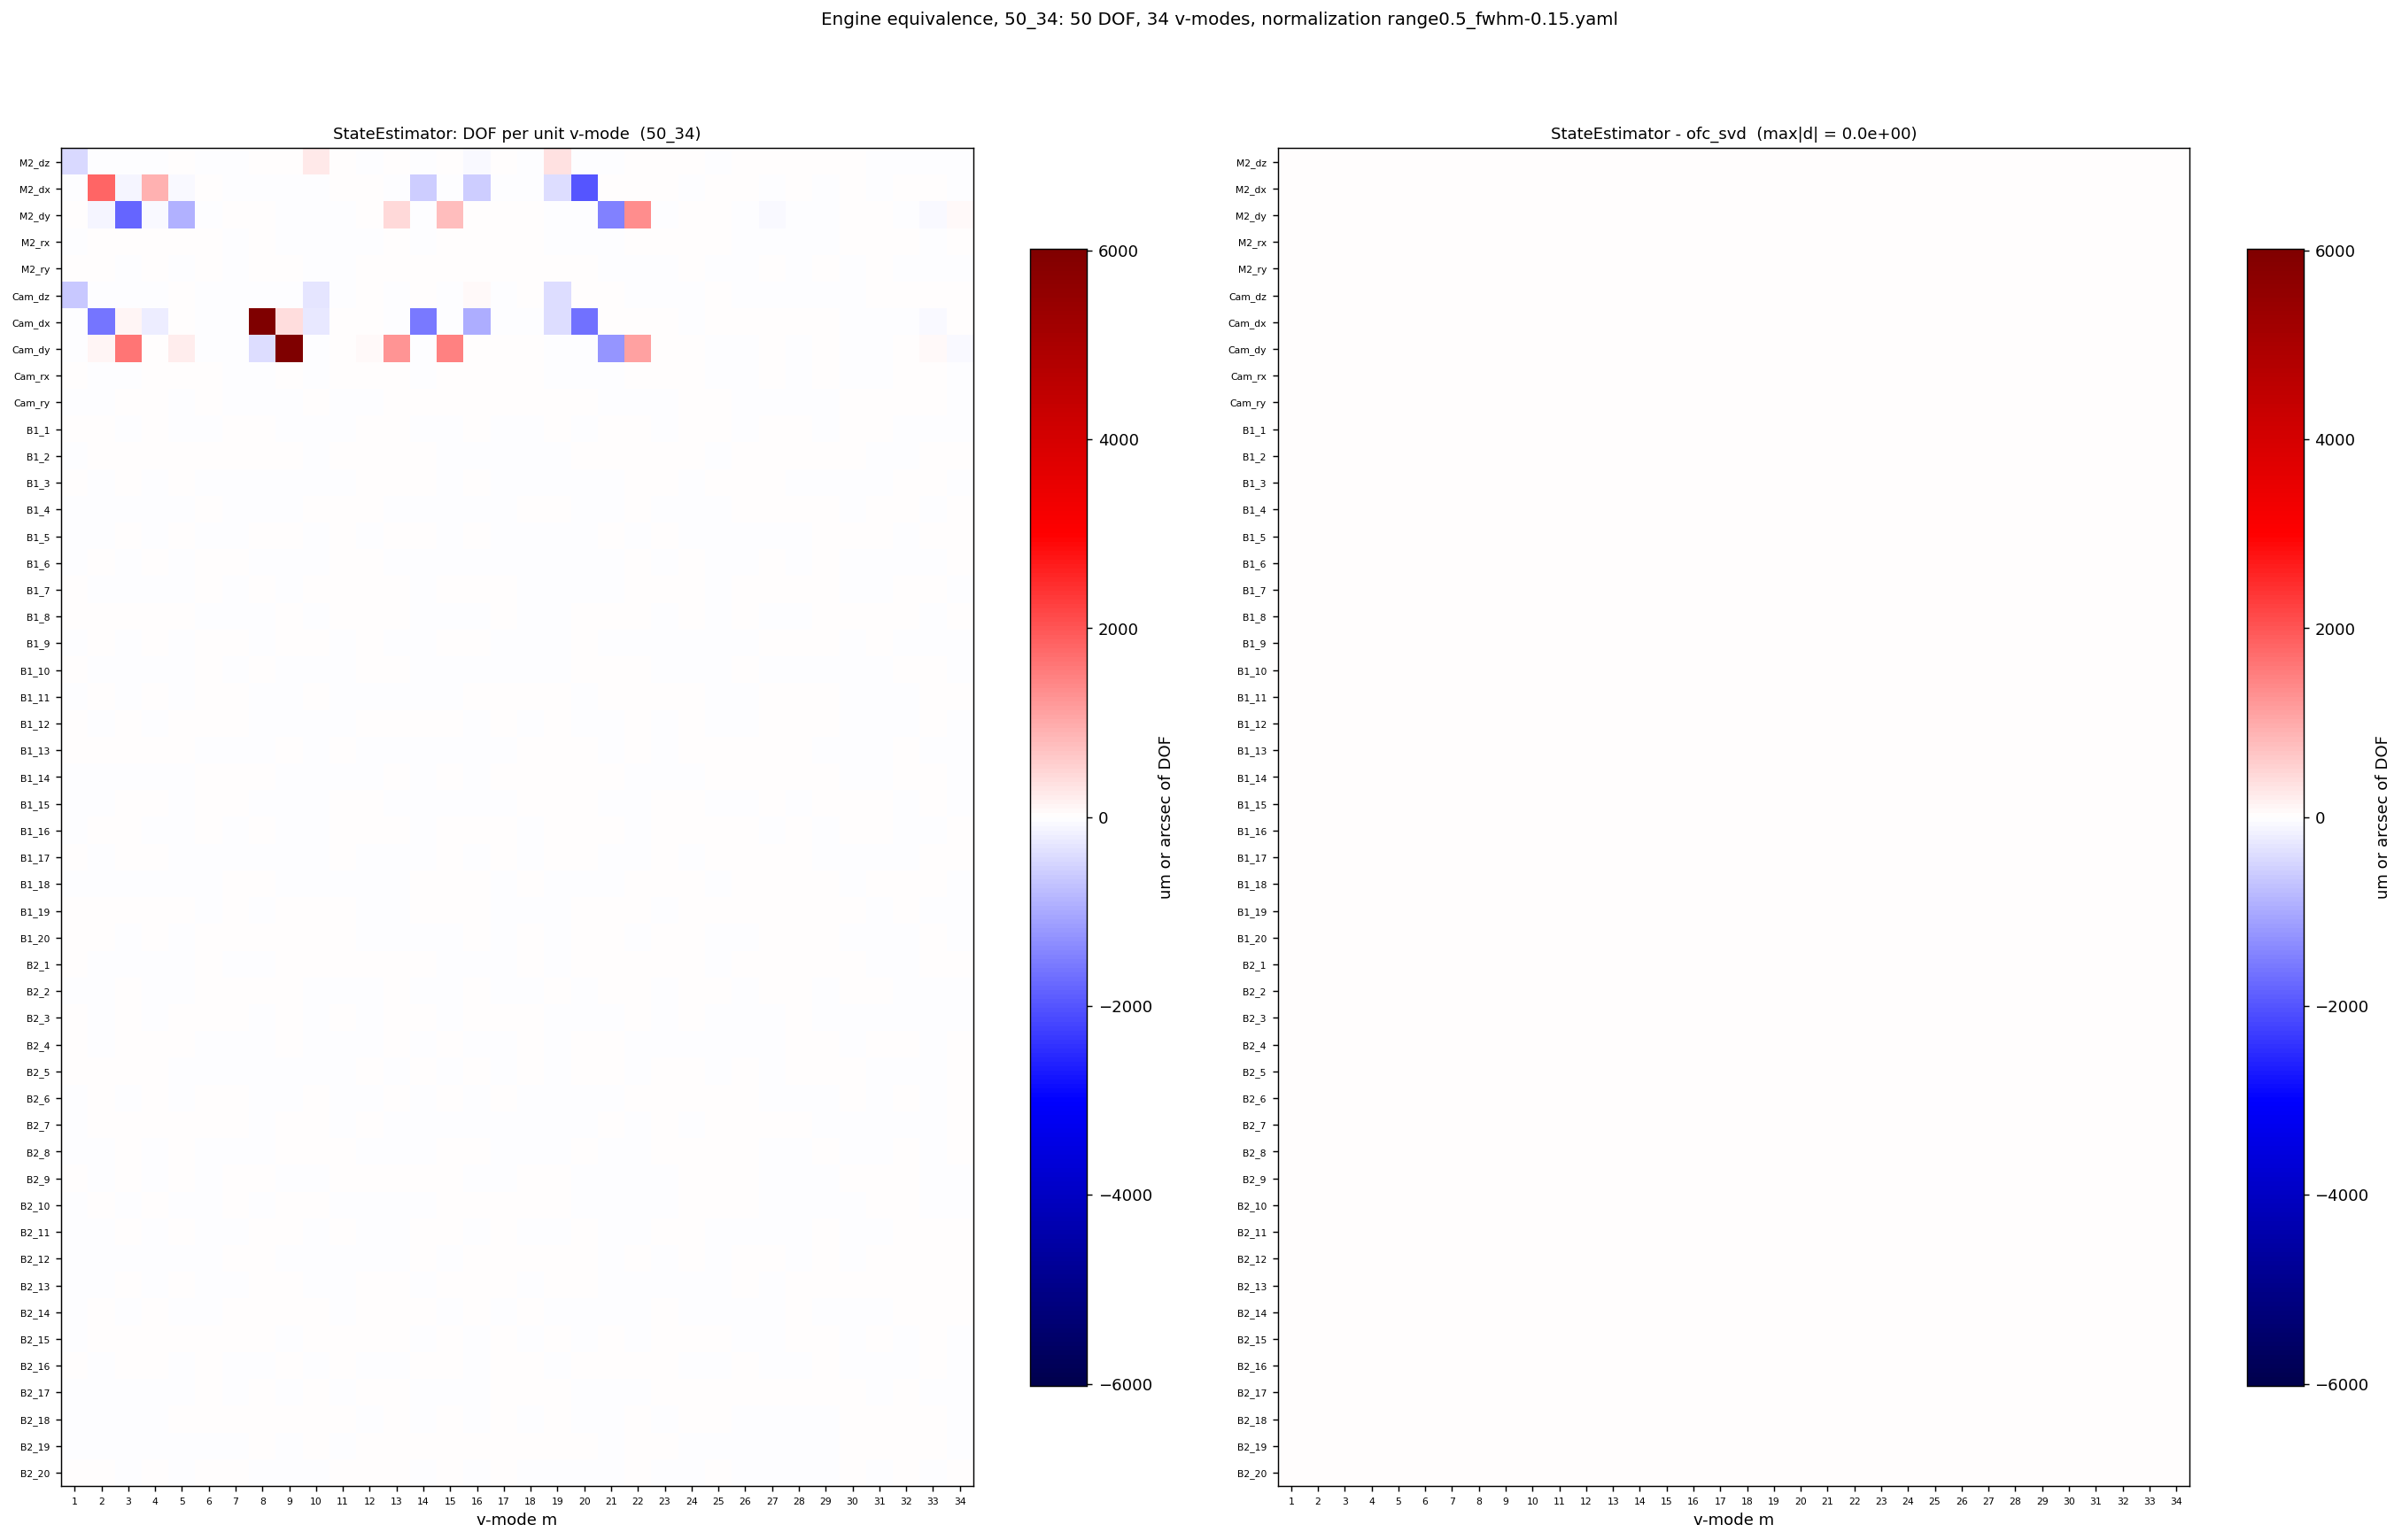

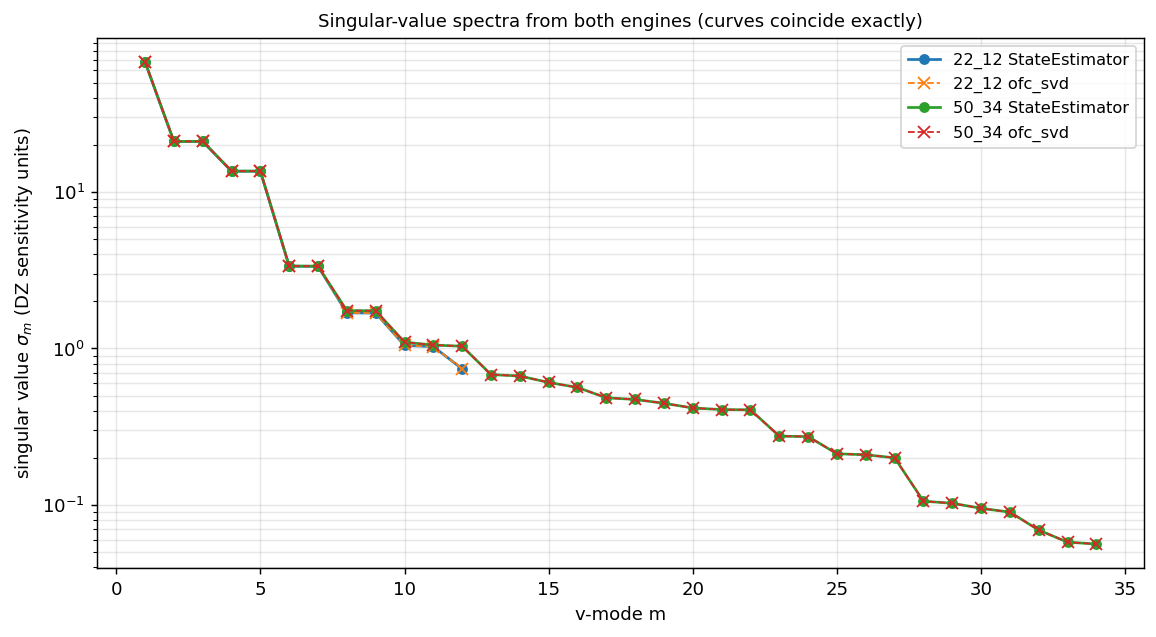


Summary
    scheme  result    max|dDOF| (um or arcsec)       min|cos|
     22_12    PASS                   0.000e+00   1.0000000000
     50_34    PASS                   0.000e+00   1.0000000000

StateEstimator and ofc_svd are one engine. Every v-mode in rubin-work comes
from aos_state.make_state_estimator, which asserts the required normalization.


In [8]:
for scheme, r in results.items():
    M_se, M_svd, labels = r["M_se"], r["M_svd"], list(r["labels"])
    diff = M_se - M_svd
    vmax = float(np.abs(M_se).max())
    n_d, n_m = M_se.shape

    fig, axes = plt.subplots(1, 2, figsize=(max(9, 0.42 * n_m + 7),
                                            max(4.5, 0.24 * n_d + 1.6)), dpi=130)
    im0 = axes[0].imshow(M_se, cmap="seismic", vmin=-vmax, vmax=vmax, aspect="auto")
    axes[0].set_title(f"StateEstimator: DOF per unit v-mode  ({scheme})")
    fig.colorbar(im0, ax=axes[0], shrink=0.85, label="um or arcsec of DOF")

    im1 = axes[1].imshow(diff, cmap="seismic", vmin=-vmax, vmax=vmax, aspect="auto")
    axes[1].set_title(f"StateEstimator - ofc_svd  (max|d| = {np.abs(diff).max():.1e})")
    fig.colorbar(im1, ax=axes[1], shrink=0.85, label="um or arcsec of DOF")

    for ax in axes:
        ax.set_xlabel("v-mode m")
        ax.set_xticks(range(n_m))
        ax.set_xticklabels([str(m + 1) for m in range(n_m)], fontsize=6)
        ax.set_yticks(range(n_d))
        ax.set_yticklabels(labels, fontsize=6)
    fig.suptitle(f"Engine equivalence, {scheme}: {r['n_dof']} DOF, {r['n_keep']} v-modes, "
                 f"normalization {r['norm_yaml']}", fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    if OUTPUT_DIR:
        out = Path(OUTPUT_DIR) / f"vmode_svd_engine_validation_{scheme}.pdf"
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out)
        print(f"wrote {out}")
    plt.show()

# Singular-value spectra, both engines overplotted.
fig, ax = plt.subplots(figsize=(9, 5), dpi=130)
for scheme, r in results.items():
    m = np.arange(1, r["n_keep"] + 1)
    ax.semilogy(m, r["sigma_se"], "o-", ms=5, label=f"{scheme} StateEstimator")
    ax.semilogy(m, r["sigma_svd"], "x--", ms=7, lw=1.0, label=f"{scheme} ofc_svd")
ax.set_xlabel("v-mode m")
ax.set_ylabel(r"singular value $\sigma_m$ (DZ sensitivity units)")
ax.set_title("Singular-value spectra from both engines (curves coincide exactly)")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)
fig.tight_layout()
if OUTPUT_DIR:
    out = Path(OUTPUT_DIR) / "vmode_svd_engine_validation_sigma.pdf"
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out)
    print(f"wrote {out}")
plt.show()

print("\nSummary")
print(f"  {'scheme':>8} {'result':>7}  {'max|dDOF| (um or arcsec)':>26} {'min|cos|':>14}")
for scheme, r in results.items():
    print(f"  {scheme:>8} {'PASS' if r['passed'] else 'FAIL':>7}  "
          f"{r['d_dof']:26.3e} {r['cos'].min():14.10f}")
print("\nStateEstimator and ofc_svd are one engine. Every v-mode in rubin-work comes")
print("from aos_state.make_state_estimator, which asserts the required normalization.")